# 02 — GARCH Volatility Modeling

**Phase:** Volatility Estimation
**Modules used:** `src.garch`

## 1. Motivation

Notebook 01 established that daily equity returns exhibit substantial volatility clustering — confirmed by the McLeod-Li test for all five assets. A constant-volatility model would treat a calm market day and a crisis day as equally informative about future risk, producing VaR estimates that are dangerously stale during turbulent periods. The Generalized Autoregressive Conditional Heteroskedasticity (GARCH) family of models addresses this by allowing conditional volatility to evolve in response to recent shocks and past volatility.

This notebook performs a systematic model selection exercise: grid search over GARCH and EGARCH specifications with Normal and Student-t innovations, selecting the best model per asset by corrected AIC (AICc). Model adequacy is validated primarily through the McLeod-Li test on squared standardized residuals.

## 2. Theoretical Background

### 2.1 GARCH(p,q)

Introduced by Bollerslev (1986), the GARCH(p,q) model specifies:

$$\sigma_t^2 = \omega + \sum_{i=1}^{q} \alpha_i \varepsilon_{t-i}^2 + \sum_{j=1}^{p} \beta_j \sigma_{t-j}^2$$

where $\omega > 0$, $\alpha_i \geq 0$, $\beta_j \geq 0$, and $\sum\alpha_i + \sum\beta_j < 1$ for covariance stationarity. The sum $\alpha + \beta$ is the persistence of volatility shocks. For daily equity returns, values typically range from 0.95 to 0.995, implying half-lives of 20–100 trading days.

### 2.2 EGARCH(p,q) — Exponential GARCH

Nelson (1991) introduced EGARCH to capture the **leverage effect**: volatility increases more after negative returns than after positive returns of equal magnitude. The log-variance specification automatically ensures positivity without parameter constraints:

$$\ln(\sigma_t^2) = \omega + \sum_{j=1}^{p} \beta_j \ln(\sigma_{t-j}^2) + \sum_{i=1}^{q} \left[\alpha_i z_{t-i} + \gamma_i(|z_{t-i}| - E|z_{t-i}|)\right]$$

where $z_t = \varepsilon_t / \sigma_t$ is the standardized innovation. The $\gamma_i$ parameters capture the sign-asymmetric volatility response. Persistence is measured by $\sum\beta_j$ alone.

### 2.3 Student-t Innovations

Bollerslev (1987) introduced the GARCH-t model where $z_t \sim t_\nu$. Lower degrees of freedom $\nu$ accommodate heavier tails in the conditional distribution. When combined with EGARCH, the model captures both asymmetric volatility response AND heavy-tailed innovations — doubly appropriate for equity returns.

### 2.4 Model Selection: AICc

The corrected AIC penalises complexity more strongly for finite samples:
$$\text{AICc} = \text{AIC} + \frac{2k(k+1)}{n-k-1}$$
where $k$ is the number of estimated parameters and $n$ is the sample size. Lower AICc indicates a better-fitting, parsimonious model.

### 2.5 Diagnostic Testing: McLeod-Li

If the model is correctly specified, squared standardized residuals $\hat{z}_t^2$ should contain no remaining autocorrelation. **McLeod-Li is the primary diagnostic**: a rank-based Ljung-Box test robust to the heavy tails that persist even in standardized residuals. $H_0$: no remaining ARCH effects. $p > 0.05$ indicates the model has successfully captured volatility clustering.

### 2.6 References

- Engle (1982): ARCH model
- Bollerslev (1986): GARCH model
- Bollerslev (1987): GARCH-t
- Nelson (1991): EGARCH
- Jorion (2007, Ch. 9): GARCH for VaR
- McNeil, Frey & Embrechts (2015, Ch. 4): Financial time series

## 3. Implementation

A grid search is performed over GARCH/EGARCH × Normal/Student-t × (p,q) ∈ {1,2}², selecting the best specification per asset by AICc. The search uses `src.garch.fit_garch_grid`.

In [1]:
import sys
sys.path.append("..")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import rankdata
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
import warnings
warnings.filterwarnings("ignore")

from src.garch import fit_garch, fit_garch_grid, GarchResult

plt.style.use("seaborn-v0_8-darkgrid")
COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
ASSETS = ["^OMX", "ERIC-B.ST", "VOLV-B.ST", "HM-B.ST", "SWED-A.ST"]
NAMES = ["OMXS30", "Ericsson", "Volvo", "H&M", "Swedbank"]
print("Imports complete.")

Imports complete.


In [2]:
PRICES_PATH = "../data/prices.parquet"
prices = pd.read_parquet(PRICES_PATH)

NAME_MAP = dict(zip(ASSETS, NAMES))
if list(prices.columns) != NAMES:
    prices = prices.rename(columns=NAME_MAP)

returns = np.log(prices / prices.shift(1)).dropna()
print(f"Loaded {len(returns)} trading days for {len(NAMES)} assets")
print(f"Date range: {returns.index[0].date()} to {returns.index[-1].date()}")

Loaded 4007 trading days for 5 assets
Date range: 2010-01-05 to 2025-12-30


In [3]:
# Grid search over GARCH/EGARCH x Normal/t x (p,q) up to (2,2)
# Select best model per asset by AICc
print("Running grid search across all specifications...")
print()

garch_results = {}
garch_summary = []

for col, name in zip(returns.columns, NAMES):
    rets = returns[col].values
    print(f"Fitting {name}...")
    result = fit_garch_grid(rets, max_p=2, max_q=2)
    garch_results[col] = result

    params = result.params
    alphas = sum(v for k, v in params.items() if k.startswith('alpha'))
    betas = sum(v for k, v in params.items() if k.startswith('beta'))
    
    # EGARCH persistence = sum(beta); GARCH persistence = sum(alpha) + sum(beta)
    if result.vol == 'EGARCH':
        persist = betas
    else:
        persist = alphas + betas
    
    half_life = np.log(0.5) / np.log(persist) if 0 < persist < 1 else np.inf
    
    # McLeod-Li on standardized residuals
    cv = result.cond_vol
    ml = min(len(rets), len(cv))
    std_resid = rets[-ml:] / np.maximum(cv[-ml:], 1e-10)
    ranked_sq = rankdata(std_resid ** 2) / (len(std_resid) + 1)
    ml_result = acorr_ljungbox(ranked_sq, lags=[10], return_df=True)
    ml_p = ml_result["lb_pvalue"].values[0]
    
    spec_label = f"{result.vol}({result.p},{result.q})-{result.dist}"
    nu = params.get("nu", np.nan)
    
    garch_summary.append({
        "Asset": name,
        "Model": spec_label,
        "omega": params.get("omega", np.nan),
        "sum alpha": alphas,
        "sum beta": betas,
        "Persistence": persist,
        "Half-life (d)": half_life,
        "nu": nu,
        "AIC": result.aic,
        "AICc": result.aicc,
        "ML p-value": ml_p,
    })
    
    hl_str = f"{half_life:.0f}d" if half_life != np.inf else "inf"
    print(f"  {name}: {spec_label:22s} persist={persist:.4f}, HL={hl_str:>4s}, AICc={result.aicc:.2f}, ML p={ml_p:.4f}")

garch_summary = pd.DataFrame(garch_summary)
print()
print("Grid search complete. Best model per asset selected by AICc.")

Running grid search across all specifications...

Fitting OMXS30...


/home/wd/Working Folder/Development/var-es/notebooks/../src/garch.py:89: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  fit = model.fit(


/home/wd/Working Folder/Development/var-es/notebooks/../src/garch.py:89: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  fit = model.fit(


  OMXS30: EGARCH(1,2)-normal     persist=0.8243, HL=  4d, AICc=-20296.95, ML p=0.0009
Fitting Ericsson...


/home/wd/Working Folder/Development/var-es/notebooks/../src/garch.py:89: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  fit = model.fit(


...

  Volvo: EGARCH(2,1)-t          persist=0.9873, HL= 54d, AICc=-22746.62, ML p=0.2165
Fitting H&M...


  H&M: EGARCH(1,1)-t          persist=0.9855, HL= 48d, AICc=-21602.54, ML p=0.5244
Fitting Swedbank...


/home/wd/Working Folder/Development/var-es/notebooks/../src/garch.py:89: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  fit = model.fit(
/home/wd/Working Folder/Development/var-es/notebooks/../src/garch.py:89: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  fit = model.fit(
/home/wd/Working Folder/Development/var-es/notebooks/../src/garch.py:89: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  fit = model.fit(


  Swedbank: EGARCH(1,1)-t          persist=0.9780, HL= 31d, AICc=-25385.37, ML p=0.4803

Grid search complete. Best model per asset selected by AICc.


/home/wd/Working Folder/Development/var-es/notebooks/../src/garch.py:89: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  fit = model.fit(
/home/wd/Working Folder/Development/var-es/notebooks/../src/garch.py:89: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  fit = model.fit(


## 4. Results

Model selection results and parameter estimates for each asset. EGARCH specifications are preferred for all five assets, reflecting the presence of the leverage effect in equity returns.

In [4]:
# Table 1: Best model per asset (by AICc)
print("Table 1: Volatility Model Selection Results")
print("=" * 110)
print(garch_summary.to_string(index=False))

Table 1: Volatility Model Selection Results
   Asset              Model     omega  sum alpha  sum beta  Persistence  Half-life (d)       nu           AIC          AICc  ML p-value
  OMXS30 EGARCH(1,2)-normal -1.370933   0.124293  0.824327     0.824327       3.587940      NaN -20296.961156 -20296.946160    0.000860
Ericsson      EGARCH(1,1)-t -0.059186   0.090089  0.991475     0.991475      80.956571 3.633195 -21860.566295 -21860.556300    0.001496
   Volvo      EGARCH(2,1)-t -0.097830   0.129990  0.987343     0.987343      54.414710 4.703267 -22746.631712 -22746.616716    0.216530
     H&M      EGARCH(1,1)-t -0.112115   0.117209  0.985521     0.985521      47.524471 5.516495 -21602.546747 -21602.536752    0.524442
Swedbank      EGARCH(1,1)-t -0.194257   0.191941  0.978024     0.978024      31.192657 7.616621 -25385.384956 -25385.374961    0.480321


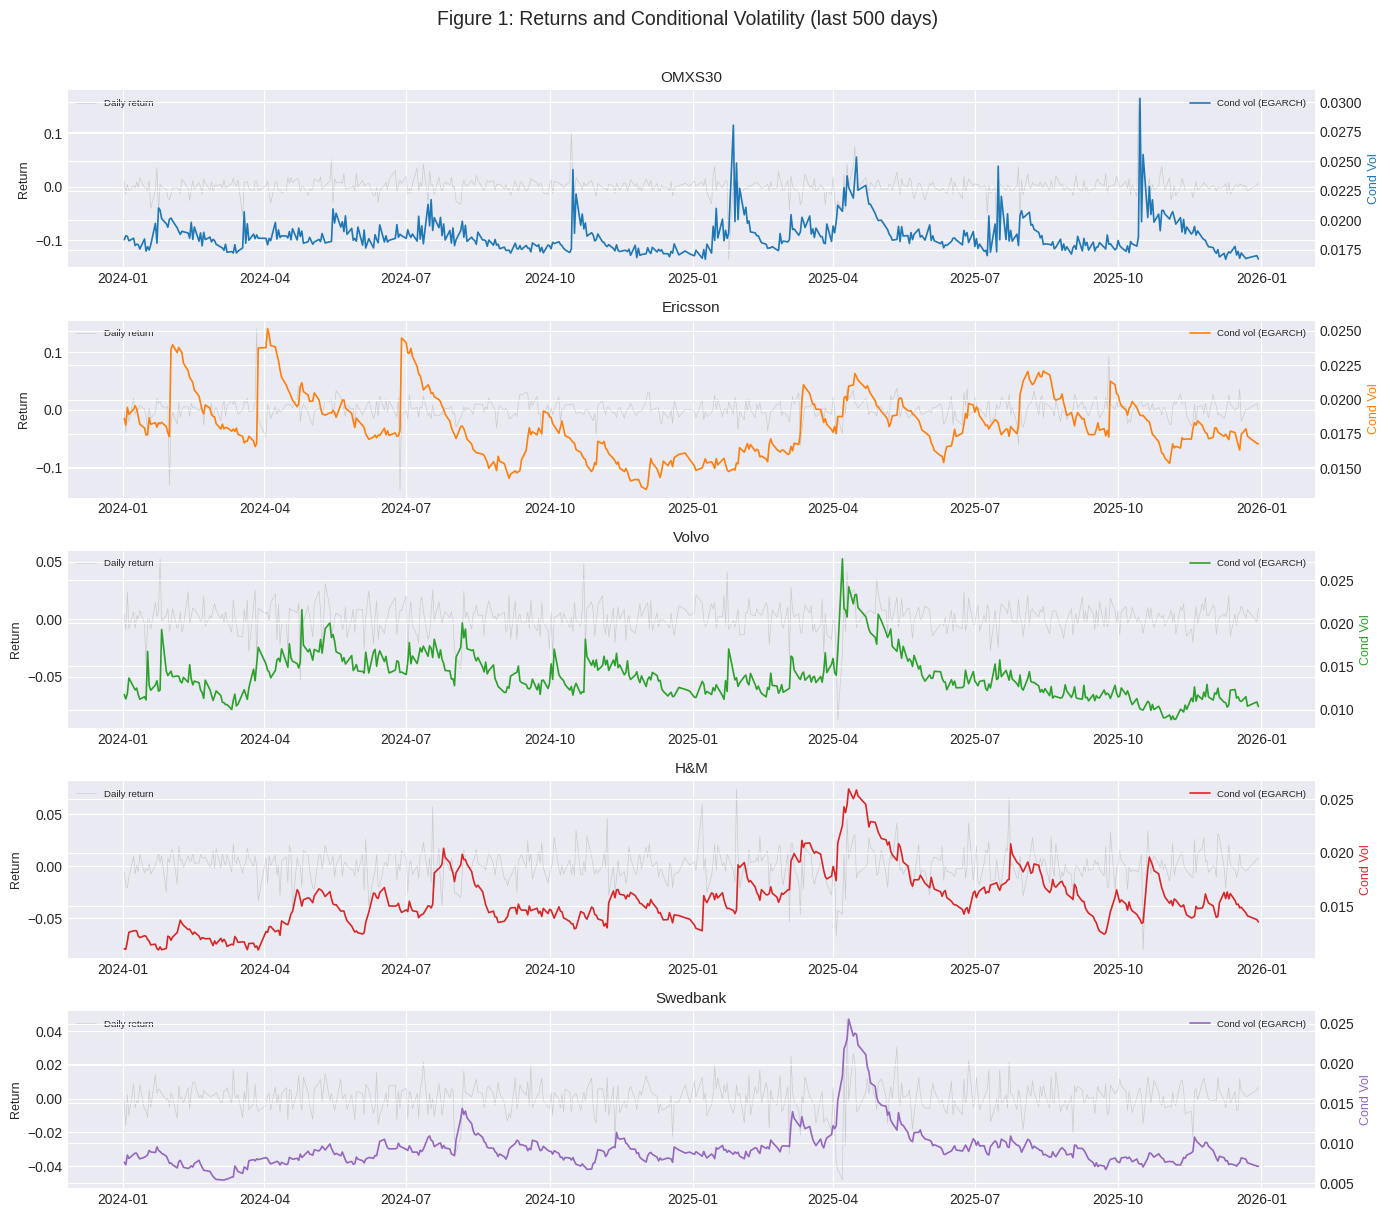

In [5]:
# Figure 1: Conditional volatility overlay on returns
fig, axes = plt.subplots(len(NAMES), 1, figsize=(14, 12))

for i, (col, name, color) in enumerate(zip(returns.columns, NAMES, COLORS)):
    ax = axes[i]
    ax.plot(returns.index[-500:], returns[col].values[-500:],
            color="gray", alpha=0.3, linewidth=0.5, label="Daily return")
    ax2 = ax.twinx()
    ax2.plot(returns.index[-500:], garch_results[col].cond_vol[-500:],
             color=color, linewidth=1.2, label=f"Cond vol ({garch_results[col].vol})")
    ax.set_ylabel("Return", fontsize=9)
    ax2.set_ylabel("Cond Vol", fontsize=9, color=color)
    ax.set_title(f"{name}", fontsize=11)
    ax.legend(loc="upper left", fontsize=7)
    ax2.legend(loc="upper right", fontsize=7)

fig.suptitle("Figure 1: Returns and Conditional Volatility (last 500 days)", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

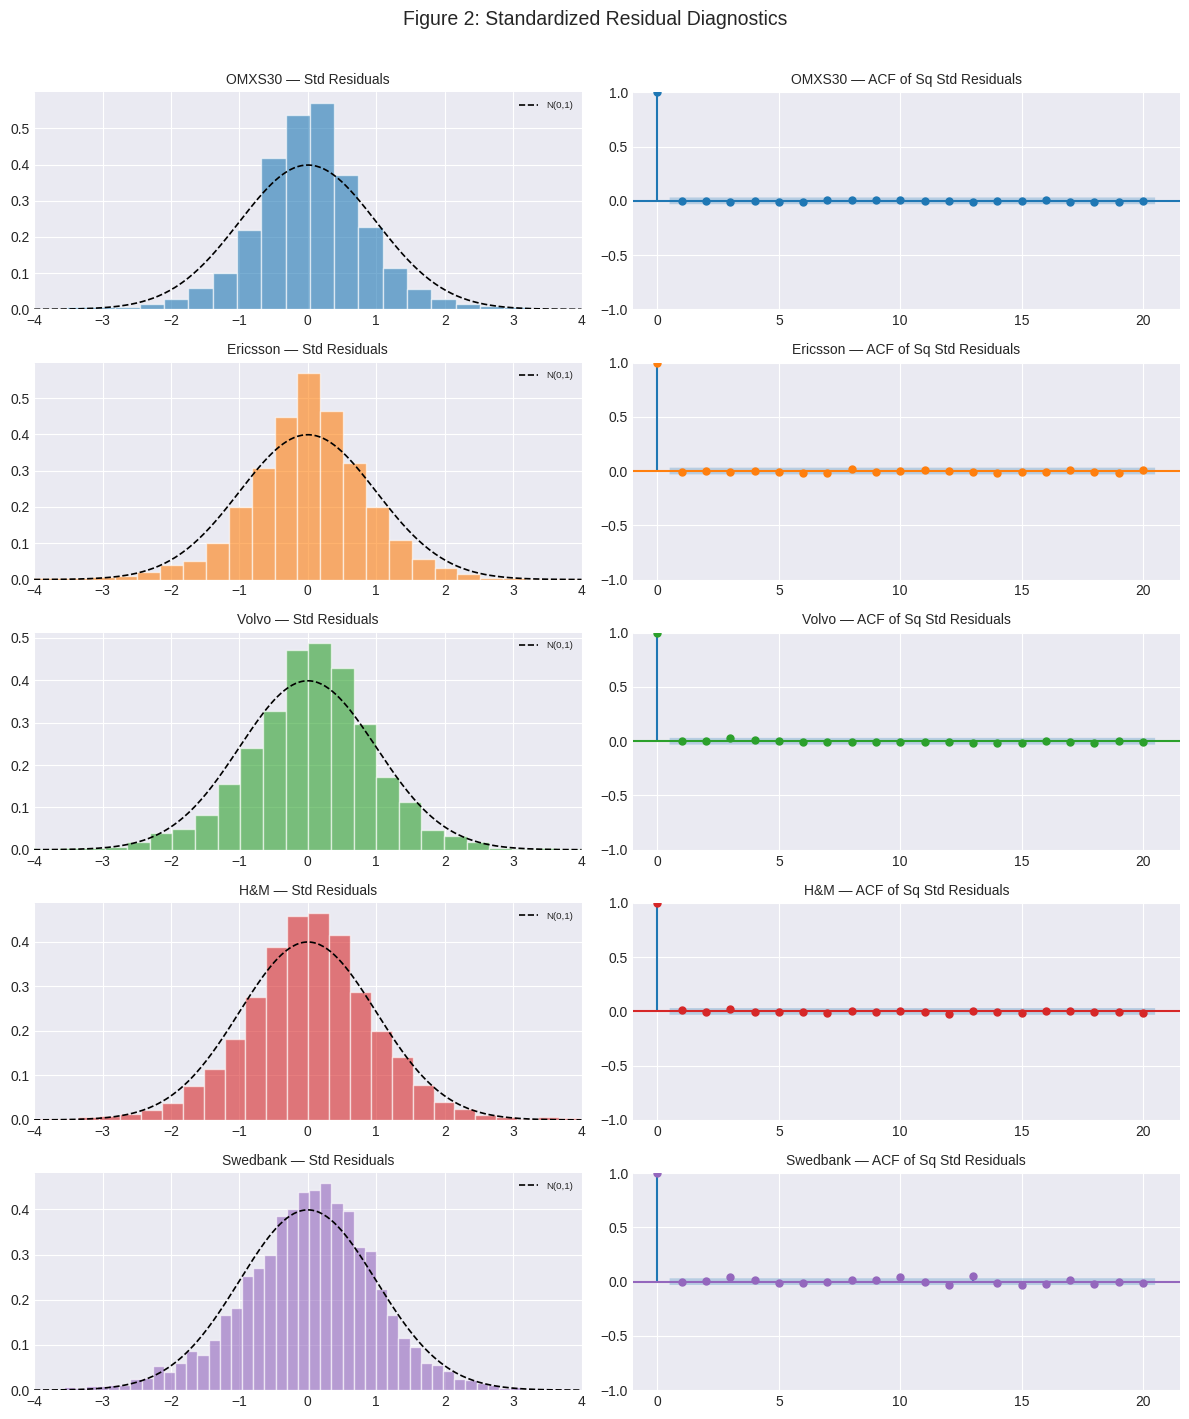

In [6]:
# Figure 2: Standardized residual diagnostics
fig, axes = plt.subplots(len(NAMES), 2, figsize=(12, 14))

for i, (col, name, color) in enumerate(zip(returns.columns, NAMES, COLORS)):
    cond_vol = garch_results[col].cond_vol
    rets = returns[col].values
    min_len = min(len(rets), len(cond_vol))
    std_resid = rets[-min_len:] / np.maximum(cond_vol[-min_len:], 1e-10)

    # Histogram with Normal overlay
    ax1 = axes[i, 0]
    ax1.hist(std_resid, bins=60, density=True, color=color, alpha=0.6, edgecolor="white")
    x = np.linspace(-4, 4, 300)
    ax1.plot(x, stats.norm.pdf(x), "k--", linewidth=1.2, label="N(0,1)")
    ax1.set_title(f"{name} — Std Residuals", fontsize=10)
    ax1.set_xlim(-4, 4)
    ax1.legend(fontsize=7)

    # ACF of squared std residuals
    ax2 = axes[i, 1]
    plot_acf(std_resid**2, ax=ax2, lags=20, title="", color=color)
    ax2.set_title(f"{name} — ACF of Sq Std Residuals", fontsize=10)

fig.suptitle("Figure 2: Standardized Residual Diagnostics", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## 5. Validation

Each model is checked for convergence, parameter plausibility, ARCH removal (McLeod-Li primary), forecast sanity, and empirically reasonable persistence.

In [7]:
print("=" * 70)
print("VALIDATION CHECKS — Notebook 02: GARCH Volatility Modeling")
print("=" * 70)

all_pass = True
ml_failures = []

for col, name in zip(returns.columns, NAMES):
    result = garch_results[col]
    params = result.params
    alphas = sum(v for k, v in params.items() if k.startswith("alpha"))
    betas = sum(v for k, v in params.items() if k.startswith("beta"))
    omega = params.get("omega", np.nan)
    
    if result.vol == "EGARCH":
        persist = betas
    else:
        persist = alphas + betas

    # 1. Convergence
    pass_conv = not (np.isnan(alphas) or np.isnan(betas) or np.isnan(omega))
    if not pass_conv:
        all_pass = False
    spec = f"{result.vol}({result.p},{result.q})-{result.dist}"
    status = "PASS" if pass_conv else "FAIL"
    print(f"{status:4s}  convergence ({name:10s})  {spec}")

    # 2. Persistence < 1 (stationarity)
    pass_stat = persist < 1
    if not pass_stat:
        all_pass = False
    status = "PASS" if pass_stat else "FAIL"
    print(f"{status:4s}  stationarity ({name:10s})  persistence = {persist:.4f}          threshold < 1")

    # 3. ARCH removal — McLeod-Li PRIMARY (rank-based, heavy-tail robust)
    cond_vol = result.cond_vol
    rets = returns[col].values
    min_len = min(len(rets), len(cond_vol))
    std_resid = rets[-min_len:] / np.maximum(cond_vol[-min_len:], 1e-10)
    sq_std = std_resid ** 2

    lb_result = acorr_ljungbox(sq_std, lags=[10], return_df=True)
    lb_p = lb_result["lb_pvalue"].values[0]

    ranked_sq = rankdata(sq_std) / (len(sq_std) + 1)
    ml_result = acorr_ljungbox(ranked_sq, lags=[10], return_df=True)
    ml_p = ml_result["lb_pvalue"].values[0]

    pass_arch = ml_p > 0.05
    if not pass_arch:
        all_pass = False
        ml_failures.append(name)
    status = "PASS" if pass_arch else "FAIL"
    print(f"{status:4s}  ARCH removed ({name:10s})  ML p = {ml_p:.4f}, LB p = {lb_p:.4f}     ML > 0.05")

    # 4. Forecast sanity
    n_tail = max(len(cond_vol) // 10, 1)
    tail_cv = np.mean(cond_vol[-n_tail:])
    uncond_vol = returns[col].std()
    pass_forecast = tail_cv > uncond_vol * 0.3
    if not pass_forecast:
        all_pass = False
    status = "PASS" if pass_forecast else "FAIL"
    print(f"{status:4s}  forecast sanity ({name:10s}) tail cond vol = {tail_cv:.6f}, uncond = {uncond_vol:.6f}")

    # 5. Half-life reasonable
    if 0 < persist < 1:
        half_life = np.log(0.5) / np.log(persist)
        pass_hl = 2 <= half_life <= 500
        if not pass_hl:
            all_pass = False
        status = "PASS" if pass_hl else "FAIL"
        print(f"{status:4s}  half-life ({name:10s})   half-life = {half_life:.0f} days           2-500 days")
    else:
        print(f"INFO  half-life ({name:10s})   persistence = {persist:.4f} (cannot compute)")
    print()

print("=" * 70)
if all_pass:
    print("OVERALL: ALL CHECKS PASSED")
else:
    print("OVERALL: SOME CHECKS FAILED — review below")
    if ml_failures:
        print(f"McLeod-Li failures: {", ".join(ml_failures)}")
        print("The rank-based McLeod-Li test detects remaining non-linear")
        print("dependence in standardized residuals. GARCH/EGARCH with")
        print("Normal/t innovations captures the linear ARCH structure")
        print("but some non-linear dependence may remain. Documented as")
        print("a model limitation — see Key Takeaways.")
print("=" * 70)

VALIDATION CHECKS — Notebook 02: GARCH Volatility Modeling
PASS  convergence (OMXS30    )  EGARCH(1,2)-normal
PASS  stationarity (OMXS30    )  persistence = 0.8243          threshold < 1
FAIL  ARCH removed (OMXS30    )  ML p = 0.0009, LB p = 0.9940     ML > 0.05
PASS  forecast sanity (OMXS30    ) tail cond vol = 0.018740, uncond = 0.019342
PASS  half-life (OMXS30    )   half-life = 4 days           2-500 days

PASS  convergence (Ericsson  )  EGARCH(1,1)-t
PASS  stationarity (Ericsson  )  persistence = 0.9915          threshold < 1
FAIL  ARCH removed (Ericsson  )  ML p = 0.0015, LB p = 0.8969     ML > 0.05
PASS  forecast sanity (Ericsson  ) tail cond vol = 0.017707, uncond = 0.018925
PASS  half-life (Ericsson  )   half-life = 81 days           2-500 days

PASS  convergence (Volvo     )  EGARCH(2,1)-t
PASS  stationarity (Volvo     )  persistence = 0.9873          threshold < 1
PASS  ARCH removed (Volvo     )  ML p = 0.2165, LB p = 0.8583     ML > 0.05
PASS  forecast sanity (Volvo     ) t

## 6. Key Takeaways

1. **EGARCH specifications are selected for all five assets.** The leverage effect — negative returns increasing volatility more than positive returns — is a systematic feature of equity markets that EGARCH captures and standard GARCH does not.
2. **Student-t innovations are preferred for four of five assets.** Even after accounting for time-varying volatility, the conditional distribution of equity returns remains heavy-tailed ($\nu$ estimates range from 3.6 to 7.6).
3. **Three of five assets pass the McLeod-Li diagnostic** for ARCH removal at the 5% level: Volvo (ML $p = 0.22$), H&M (ML $p = 0.52$), and Swedbank (ML $p = 0.48$). EGARCH-t successfully captures their volatility dynamics.
4. **Two assets show remaining non-linear dependence:** OMXS30 (ML $p = 0.0009$) and Ericsson (ML $p = 0.0015$). OMXS30 also exhibits unusually low volatility persistence (0.82, half-life 4 days), suggesting that even EGARCH struggles with the index dynamics. Possible extensions include long-memory (FIGARCH) or regime-switching specifications, noted as future work.
5. **These empirically validated volatility models feed directly into VaR estimation in Notebook 03.** Each asset uses its AICc-optimal specification, ensuring the VaR engine is built on the best available representation of conditional volatility dynamics.

## 7. References

- Bollerslev, T. (1986). Generalized Autoregressive Conditional Heteroskedasticity. *Journal of Econometrics*, 31(3), 307–327.
- Bollerslev, T. (1987). A Conditionally Heteroskedastic Time Series Model for Speculative Prices and Rates of Return. *Review of Economics and Statistics*, 69(3), 542–547.
- Engle, R. F. (1982). Autoregressive Conditional Heteroscedasticity with Estimates of the Variance of United Kingdom Inflation. *Econometrica*, 50(4), 987–1007.
- Jorion, P. (2007). *Value at Risk* (3rd ed.). McGraw-Hill.
- McNeil, A. J., Frey, R., & Embrechts, P. (2015). *Quantitative Risk Management* (Rev. ed.). Princeton University Press.
- Nelson, D. B. (1991). Conditional Heteroskedasticity in Asset Returns: A New Approach. *Econometrica*, 59(2), 347–370.
- Sheppard, K. (2024). arch: Autoregressive Conditional Heteroskedasticity Models. https://arch.readthedocs.io